# Step 13: Tracking hidden states with the Kalman filter

Companion to Lecture 4 of *Systematic Trading Notes*. Lecture 2 smoothed prices from the bottom up,
by averaging past bars. This notebook works from the top down: a state-space model says what is hidden
behind prices (a level, a slope, an acceleration), how it moves from bar to bar, and how prices relate
to it; the Kalman filter updates that model with each new bar.

The notebook builds three linear designs (level only; level + slope; level + slope + acceleration),
shows what each design follows regardless of its tuning, profiles what each hidden state captures in
different market conditions, and then covers extensions, the extended and unscented filters, and a
time-varying hedge ratio. Every number quoted in the lecture is produced here.

Variables are named by meaning: *level*, *slope*, *acceleration* (states); *q_level*, *q_slope*,
*q_acceleration* (how much each state may change per bar, the diagonal of $Q$); *r_price* (price noise,
$R$); *uncertainty* ($P$); *gain* ($K$); *surprise* (price minus forecast).

References are listed at the end.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
from plotly.subplots import make_subplots
from scipy.stats import kurtosis, norm, skew

from trading_models.data.ohlc import load_ohlc
from trading_models.plotting import MUTED, SERIES, apply_theme, save_figure

apply_theme()
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
RAW = ROOT / "data" / "raw"
FIG = ROOT / "lectures" / "04-tracking-hidden-states" / "figures"
TICKERS = ["SPY", "QQQ", "GLD", "AGG"]

## 1. Data

Adjusted daily OHLC for SPY, QQQ, GLD and AGG from `trading_models.data.ohlc`, sharing notebook 12's
cache. All filters run on log prices, so a slope is a daily log trend (shown annualised, x252).

In [2]:
ohlc = load_ohlc(TICKERS, start="1993-01-01", cache=RAW / "nb12_ohlc_long.csv")
O, H, L, C = (ohlc[f] for f in ("open", "high", "low", "close"))
for t in TICKERS:
    s = C[t].dropna()
    print(f"{t}: {s.index[0].date()} to {s.index[-1].date()}, {len(s)} bars")
qqq = C["QQQ"].dropna()
y_qqq = np.log(qqq.to_numpy())
dates = qqq.index

SPY: 1993-01-29 to 2026-10-09, 8482 bars
QQQ: 1999-03-10 to 2026-10-09, 6940 bars
GLD: 2004-11-18 to 2026-10-09, 5507 bars
AGG: 2003-09-29 to 2026-10-09, 5795 bars


## 2. The linear Kalman filter, with named variables

Each bar the filter **predicts** the hidden state forward, **compares** the forecast with the new
price (the *surprise*), and **corrects** the state by *gain* x *surprise*. The gain is large when the
filter is uncertain about its state relative to the price noise, and small otherwise.

Three designs, all on log price; the transition matrix says how the states move over one bar:

| Design | States | One-bar transition |
|---|---|---|
| Level only | level | level stays where it was |
| Level + slope | level, slope | level moves by the slope |
| Level + slope + acceleration | level, slope, acceleration | level moves by slope + 0.5 x acceleration; slope moves by acceleration |

The optional arguments are used later: `cap` caps extreme surprises (a robust update, section 8),
`r_series` lets the price noise change bar by bar, `damping` lets the slope fade.

In [3]:
def kalman(prices, transition, observe, q_diag, r_price, start_uncertainty=1.0, start_state=None,
           cap=None, r_series=None, full_q=None):
    n = transition.shape[0]
    state = np.zeros(n)
    state[0] = prices[0]
    if start_state is not None:
        state = np.array(start_state, dtype=float)
    uncertainty = np.eye(n) * start_uncertainty
    Q = np.diag(q_diag) if full_q is None else full_q
    T = len(prices)
    out = {k: np.empty(T) for k in ("forecast", "surprise", "z", "gain", "surprise_var")}
    states, sds = np.empty((T, n)), np.empty((T, n))
    z_var = 1.0                                                        # running scale of recent surprises (robust update)
    for t, price in enumerate(prices):
        r = r_price if r_series is None else r_series[t]
        state = transition @ state                                     # predict
        uncertainty = transition @ uncertainty @ transition.T + Q
        forecast = observe @ state
        surprise_var = observe @ uncertainty @ observe + r
        gain = uncertainty @ observe / surprise_var                    # trust in the new price
        surprise = price - forecast                                    # compare
        z = surprise / np.sqrt(surprise_var)
        used = surprise
        if cap is not None:
            limit = cap * np.sqrt(z_var)                                   # cap relative to the recent typical surprise
            if abs(z) > limit:
                used = np.sign(surprise) * limit * np.sqrt(surprise_var)
            z_var = (1 - 1 / 252) * z_var + (1 / 252) * min(z ** 2, limit ** 2)   # updated with past data only
        state = state + gain * used                                    # correct
        uncertainty = uncertainty - np.outer(gain, observe @ uncertainty)
        states[t], sds[t] = state, np.sqrt(np.diag(uncertainty))
        for k, v in (("forecast", forecast), ("surprise", surprise), ("z", z), ("gain", gain[0]),
                     ("surprise_var", surprise_var)):
            out[k][t] = v
    out["states"], out["sd"] = states, sds
    return out


def design(n_states, damping=1.0):
    if n_states == 1:
        return np.array([[1.0]]), np.array([1.0])
    if n_states == 2:
        return np.array([[1.0, 1.0], [0.0, damping]]), np.array([1.0, 0.0])
    return np.array([[1.0, 1.0, 0.5], [0.0, 1.0, 1.0], [0.0, 0.0, 1.0]]), np.array([1.0, 0.0, 0.0])


Q_REL = {1: np.array([1.0]), 2: np.array([1.0, 1e-2]), 3: np.array([1.0, 1e-2, 1e-4])}
NAMES = {1: "Level only", 2: "Level + slope", 3: "Level + slope + acceleration"}


def run(prices, k, r_price, q_scale=1e-4, damping=1.0, **kw):
    F, Hh = design(k, damping)
    return kalman(prices, F, Hh, Q_REL[k] * q_scale, r_price, **kw)


def ema(x, alpha):
    out = np.empty(len(x)); out[0] = x[0]
    for t in range(1, len(x)):
        out[t] = alpha * x[t] + (1 - alpha) * out[t - 1]
    return out

## 3. One hidden state, by hand

Lecture 2's toy series, filtered with the level-only design. With $q/R = 1/6$ the steady-state gain is
exactly $1/3$, the $\alpha$ of EMA(5). Started at its steady-state uncertainty, the filter reproduces
EMA(5) bar for bar: the level-only Kalman filter *is* an EMA, with $\alpha$ set by the ratio $q/R$.

For the local level model the steady-state forecast uncertainty $u$ solves $u^2 - q\,u - q\,R = 0$
and the gain is $u/(u+R)$; with $q/R = 1/6$ this gives $u = R/2$ and a gain of $1/3$.

In [4]:
toy = np.array([100, 100.3, 100.5, 100.8, 101.0, 101.3, 101.5, 108.5, 102.5, 102.8, 103.0, 103.3, 103.5, 103.8])
r_toy, q_toy = 1.0, 1.0 / 6.0
u_star = (q_toy + np.sqrt(q_toy ** 2 + 4 * q_toy * r_toy)) / 2
gain_star = u_star / (u_star + r_toy)
F1, H1 = design(1)
res = kalman(toy, F1, H1, np.array([q_toy]), r_toy, start_uncertainty=(1 - gain_star) * u_star)
ema5 = ema(toy, 1 / 3)
tab = pd.DataFrame({"price": toy, "forecast": res["forecast"], "surprise": res["surprise"],
                    "gain": res["gain"], "level": res["states"][:, 0], "EMA(5)": ema5}).round(3)
tab.index.name = "bar"
print(f"steady-state gain = {gain_star:.4f} (EMA(5) alpha = 1/3)")
display(tab)
assert np.allclose(res["states"][:, 0], ema5)
t7 = 7
print(f"bar 7 by hand: forecast {res['forecast'][t7]:.3f}, surprise {toy[t7]:.1f} - {res['forecast'][t7]:.3f} = {res['surprise'][t7]:.3f}, "
      f"level = {res['forecast'][t7]:.3f} + {res['gain'][t7]:.4f} x {res['surprise'][t7]:.3f} = {res['states'][t7, 0]:.3f}")

steady-state gain = 0.3333 (EMA(5) alpha = 1/3)


,price,forecast,surprise,gain,level,EMA(5)
bar,,,,,,
0,100.0,100.000,0.000,0.333,100.000,100.000
1,100.3,100.000,0.300,0.333,100.100,100.100
2,100.5,100.100,0.400,0.333,100.233,100.233
3,100.8,100.233,0.567,0.333,100.422,100.422
4,101.0,100.422,0.578,0.333,100.615,100.615
5,101.3,100.615,0.685,0.333,100.843,100.843
6,101.5,100.843,0.657,0.333,101.062,101.062
7,108.5,101.062,7.438,0.333,103.541,103.541
8,102.5,103.541,-1.041,0.333,103.194,103.194


bar 7 by hand: forecast 101.062, surprise 108.5 - 101.062 = 7.438, level = 101.062 + 0.3333 x 7.438 = 103.541


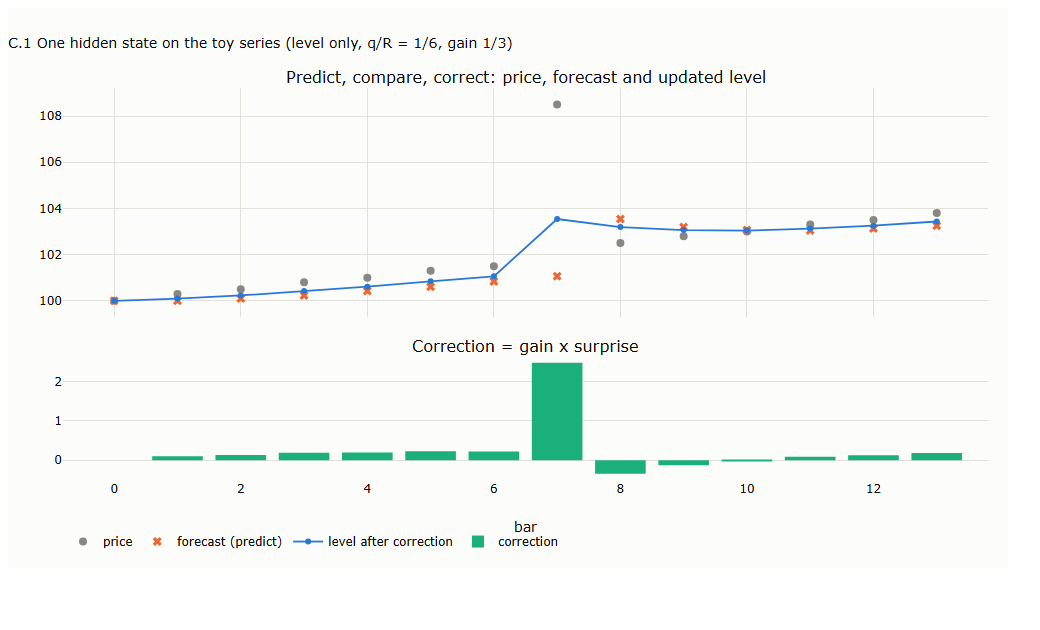

In [5]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.1, row_heights=[0.65, 0.35],
                    subplot_titles=("Predict, compare, correct: price, forecast and updated level", "Correction = gain x surprise"))
bars = np.arange(len(toy))
fig.add_scatter(x=bars, y=toy, name="price", mode="markers", marker=dict(size=8, color=MUTED), row=1, col=1)
fig.add_scatter(x=bars, y=res["forecast"], name="forecast (predict)", mode="markers", marker=dict(size=8, symbol="x", color=SERIES[1]), row=1, col=1)
fig.add_scatter(x=bars, y=res["states"][:, 0], name="level after correction", mode="lines+markers", line=dict(width=1.8, color=SERIES[0]), row=1, col=1)
fig.add_bar(x=bars, y=res["gain"] * res["surprise"], name="correction", marker_color=SERIES[2], row=2, col=1)
fig.update_layout(title="C.1 One hidden state on the toy series (level only, q/R = 1/6, gain 1/3)", height=560, width=1000,
                  margin=dict(t=80, b=60), legend=dict(orientation="h", y=-0.12, x=0))
fig.update_xaxes(title_text="bar", row=2, col=1)
save_figure(fig, "c01_predict_compare_correct", FIG)
fig

**Only the ratio $q/R$ matters.** The same ten prices, filtered with $(q, R) = (1, 4)$ and
$(10, 40)$, with the starting uncertainty scaled by the same factor: the levels and gains are
identical; only the uncertainty band rescales, by $\sqrt{10}$. (Without scaling the start the agreement
is approximate during warm-up and exact once the start has been forgotten.)

,price,"level (q=1, R=4)","level (q=10, R=40)",gain A,gain B,band A (+-1 sd),band B (+-1 sd)
0,100.0,100.000,100.000,1.000,1.000,2.000,6.325
1,101.0,100.556,100.556,0.556,0.556,1.491,4.714
2,99.0,99.862,99.862,0.446,0.446,1.336,4.224
3,102.0,100.739,100.739,0.410,0.410,1.281,4.052
4,104.0,102.036,102.036,0.398,0.398,1.261,3.989
5,103.0,102.415,102.415,0.393,0.393,1.254,3.965
6,107.0,104.210,104.210,0.391,0.391,1.251,3.957
7,106.0,104.909,104.909,0.391,0.391,1.250,3.954
8,108.0,106.116,106.116,0.391,0.391,1.250,3.952
9,110.0,107.633,107.633,0.390,0.390,1.250,3.952


band ratio B/A at the last bar: 3.162 (sqrt(10) = 3.162)


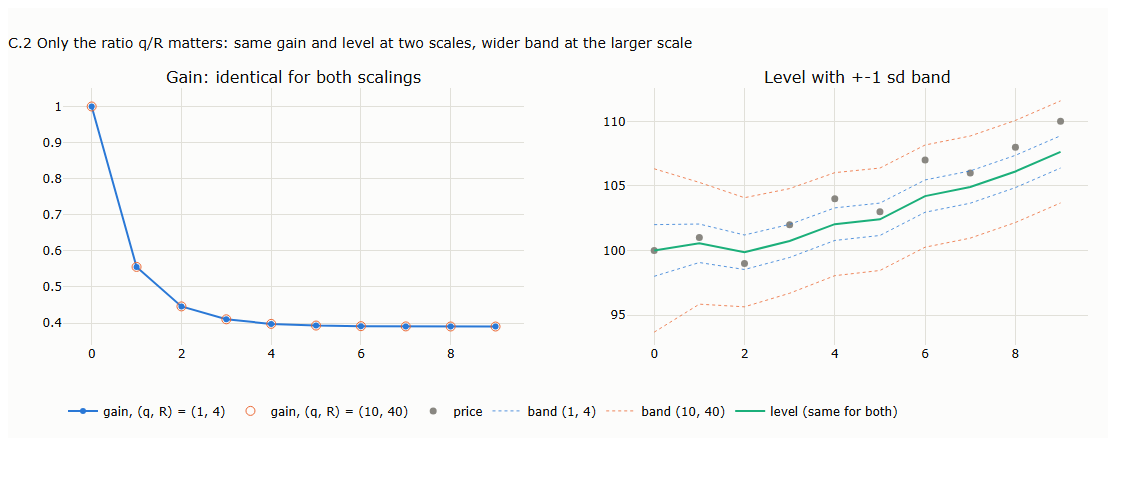

In [6]:
prices10 = np.array([100, 101, 99, 102, 104, 103, 107, 106, 108, 110.0])
A = kalman(prices10, F1, H1, np.array([1.0]), 4.0, start_uncertainty=1e6)
B = kalman(prices10, F1, H1, np.array([10.0]), 40.0, start_uncertainty=1e7)   # every variance scaled by 10, including the start
ratio_tab = pd.DataFrame({"price": prices10, "level (q=1, R=4)": A["states"][:, 0], "level (q=10, R=40)": B["states"][:, 0],
                          "gain A": A["gain"], "gain B": B["gain"], "band A (+-1 sd)": A["sd"][:, 0], "band B (+-1 sd)": B["sd"][:, 0]}).round(3)
display(ratio_tab)
assert np.allclose(A["states"], B["states"]) and np.allclose(A["gain"], B["gain"])
print(f"band ratio B/A at the last bar: {B['sd'][-1, 0] / A['sd'][-1, 0]:.3f} (sqrt(10) = {np.sqrt(10):.3f})")

fig = make_subplots(rows=1, cols=2, subplot_titles=("Gain: identical for both scalings", "Level with +-1 sd band"))
fig.add_scatter(x=np.arange(10), y=A["gain"], name="gain, (q, R) = (1, 4)", mode="lines+markers", line=dict(color=SERIES[0], width=2), row=1, col=1)
fig.add_scatter(x=np.arange(10), y=B["gain"], name="gain, (q, R) = (10, 40)", mode="markers", marker=dict(color=SERIES[1], size=9, symbol="circle-open"), row=1, col=2 - 1)
fig.add_scatter(x=np.arange(10), y=prices10, name="price", mode="markers", marker=dict(color=MUTED, size=7), row=1, col=2)
for j, (lab, R_) in enumerate((("(1, 4)", A), ("(10, 40)", B))):
    lvl, sd = R_["states"][:, 0], R_["sd"][:, 0]
    fig.add_scatter(x=np.arange(10), y=lvl + sd, mode="lines", line=dict(width=0.8, color=SERIES[j], dash="dot"), showlegend=False, row=1, col=2)
    fig.add_scatter(x=np.arange(10), y=lvl - sd, mode="lines", line=dict(width=0.8, color=SERIES[j], dash="dot"), name=f"band {lab}", row=1, col=2)
fig.add_scatter(x=np.arange(10), y=A["states"][:, 0], name="level (same for both)", mode="lines", line=dict(color=SERIES[2], width=2), row=1, col=2)
fig.update_layout(title="C.2 Only the ratio q/R matters: same gain and level at two scales, wider band at the larger scale",
                  height=430, width=1100, margin=dict(t=80, b=70), legend=dict(orientation="h", y=-0.2, x=0))
save_figure(fig, "c02_ratio_invariance", FIG)
fig

## 4. Weights on past prices and matching memory

In steady state every design is a fixed linear smoother, so its weights on past prices can be read off
its response to a single unit price. Each design is matched to EMA(20) on the variance reduction factor
$\sum_k w_k^2 = 1/20$ (Lecture 2, section 6), by solving for its price noise $R$. The level-only design
then reproduces EMA(20) exactly; the slope designs put negative weights on old prices.

In [7]:
def level_weights(k, r_price, n=400, warm=3000, **kw):
    z = np.zeros(warm + n)
    base = run(z, k, r_price, **kw)["states"][:, 0]
    z[warm] = 1.0
    return (run(z, k, r_price, **kw)["states"][:, 0] - base)[warm:]


def match_r(k, target_vrf=1 / 20, **kw):
    lo, hi = 1e-7, 1e4
    for _ in range(70):
        mid = np.sqrt(lo * hi)
        w = level_weights(k, mid, **kw)
        lo, hi = (mid, hi) if (w ** 2).sum() / w.sum() ** 2 > target_vrf else (lo, mid)
    return mid


R_MATCH = {k: match_r(k) for k in (1, 2, 3)}
alpha20 = 2 / 21
rows = {}
for k in (1, 2, 3):
    w = level_weights(k, R_MATCH[k])
    ages = np.arange(len(w))
    rows[NAMES[k]] = {"price noise R (matched)": R_MATCH[k], "average age (bars)": (ages * w).sum() / w.sum(),
                      "variance reduction": (w ** 2).sum() / w.sum() ** 2, "smallest weight": w.min()}
w_ema = alpha20 * (1 - alpha20) ** np.arange(400)
rows["EMA(20)"] = {"price noise R (matched)": np.nan, "average age (bars)": (np.arange(400) * w_ema).sum() / w_ema.sum(),
                   "variance reduction": (w_ema ** 2).sum() / w_ema.sum() ** 2, "smallest weight": w_ema.min()}
display(pd.DataFrame(rows).T.round(4))
assert np.allclose(level_weights(1, R_MATCH[1])[:200], w_ema[:200], atol=1e-6)

,price noise R (matched),average age (bars),variance reduction,smallest weight
Level only,0.0100,9.5000,0.05,0.0000
Level + slope,0.2001,-0.0003,0.05,-0.0039
Level + slope + acceleration,12.4918,-0.8345,0.05,-0.0065
EMA(20),NaN,9.5000,0.05,0.0000


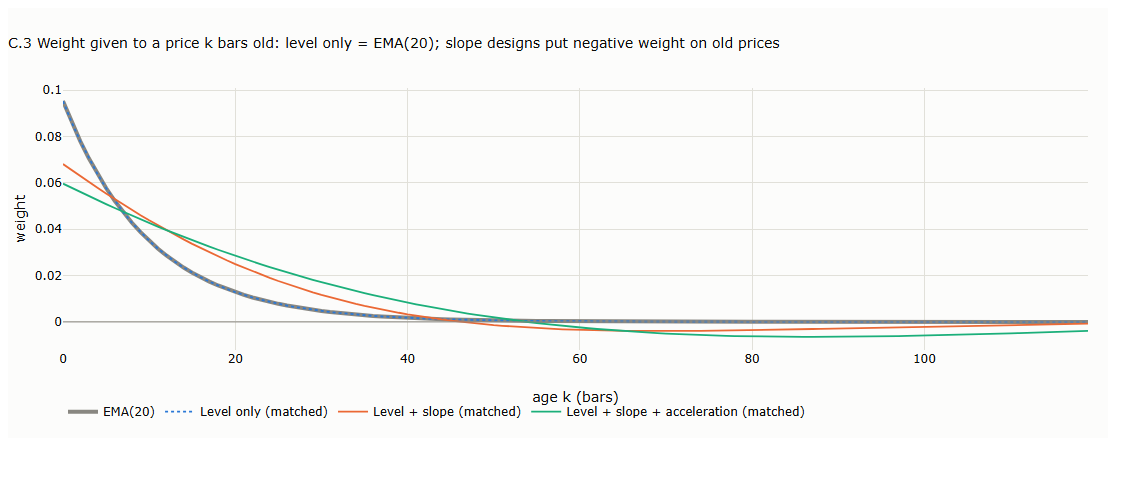

In [8]:
fig = go.Figure()
fig.add_scatter(x=np.arange(120), y=w_ema[:120], name="EMA(20)", mode="lines", line=dict(width=4, color=MUTED))
for j, k in enumerate((1, 2, 3)):
    fig.add_scatter(x=np.arange(120), y=level_weights(k, R_MATCH[k])[:120], name=f"{NAMES[k]} (matched)", mode="lines",
                    line=dict(width=1.8, color=SERIES[j], dash="dot" if k == 1 else "solid"))
fig.add_hline(y=0, line=dict(width=1, color=MUTED))
fig.update_layout(title="C.3 Weight given to a price k bars old: level only = EMA(20); slope designs put negative weight on old prices",
                  xaxis_title="age k (bars)", yaxis_title="weight", height=430, width=1100, margin=dict(t=80, b=70),
                  legend=dict(orientation="h", y=-0.18, x=0))
save_figure(fig, "c03_weights", FIG)
fig

## 5. Two forms of $Q$ for the level + slope design

*Diagonal*: the level and the slope may each change at random, independently (the level can jump by
itself, as prices gap). *Derived*: only the slope receives random kicks, and the level moves because
the slope moved during the bar, which over one bar gives $Q = q\begin{pmatrix}1/3 & 1/2\\ 1/2 & 1\end{pmatrix}$
(correlation 0.87 between the two changes). Both are matched to EMA(20) on variance reduction, then
shown on a price that jumps once.

diagonal Q: bars to cover half the jump 8, overshoot 18.9% of the jump
derived Q : bars to cover half the jump 8, overshoot 20.1% of the jump


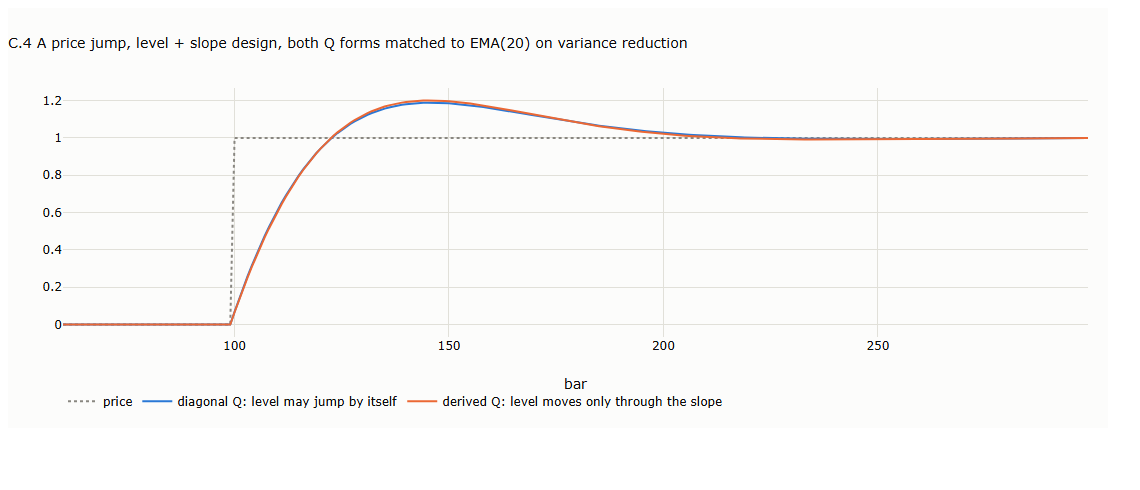

In [9]:
F2, H2 = design(2)
Q_derived = np.array([[1 / 3, 1 / 2], [1 / 2, 1.0]]) * 1e-4


def weights_q(full_q, r_price, n=400, warm=3000):
    z = np.zeros(warm + n)
    base = kalman(z, F2, H2, None, r_price, full_q=full_q)["states"][:, 0]
    z[warm] = 1.0
    return (kalman(z, F2, H2, None, r_price, full_q=full_q)["states"][:, 0] - base)[warm:]


lo, hi = 1e-7, 1e4
for _ in range(70):
    mid = np.sqrt(lo * hi)
    w = weights_q(Q_derived, mid)
    lo, hi = (mid, hi) if (w ** 2).sum() / w.sum() ** 2 > 1 / 20 else (lo, mid)
R_DERIVED = mid
step = np.r_[np.zeros(100), np.ones(200)]
lev_diag = run(step, 2, R_MATCH[2], start_uncertainty=1e3)["states"][:, 0]
lev_der = kalman(step, F2, H2, None, R_DERIVED, start_uncertainty=1e3, full_q=Q_derived)["states"][:, 0]
for lab, lv in (("diagonal Q", lev_diag), ("derived Q", lev_der)):
    print(f"{lab:10s}: bars to cover half the jump {int(np.argmax(lv[100:] >= 0.5))}, overshoot {100 * (lv.max() - 1):.1f}% of the jump")
fig = go.Figure()
fig.add_scatter(x=np.arange(60, 300), y=step[60:], name="price", mode="lines", line=dict(color=MUTED, dash="dot"))
fig.add_scatter(x=np.arange(60, 300), y=lev_diag[60:], name="diagonal Q: level may jump by itself", mode="lines", line=dict(color=SERIES[0], width=2))
fig.add_scatter(x=np.arange(60, 300), y=lev_der[60:], name="derived Q: level moves only through the slope", mode="lines", line=dict(color=SERIES[1], width=2))
fig.update_layout(title="C.4 A price jump, level + slope design, both Q forms matched to EMA(20) on variance reduction",
                  xaxis_title="bar", height=420, width=1100, margin=dict(t=80, b=70), legend=dict(orientation="h", y=-0.2, x=0))
save_figure(fig, "c04_q_forms_jump", FIG)
fig

## 6. Design versus tuning

Which states a design has decides, for every setting, which kind of motion it follows with no lasting
gap and whether it overshoots a jump. Tuning only sets the speed. Each design at a slow and a very fast
setting, on a jump, a steady trend and a parabolic move (price noise $R = 1$):

In [10]:
tt = np.arange(3000.0)
tests = {"jump of 1": np.where(tt < 100, 0.0, 1.0), "steady trend (+0.01 per bar)": 0.01 * tt,
         "parabolic (1e-5 t^2)": 1e-5 * tt ** 2}
speeds = {"slow": np.array([1e-4, 1e-6, 1e-8]), "fast": np.array([1e-2, 1e-3, 1e-4])}
rows = []
for k in (1, 2, 3):
    F, Hh = design(k)
    row = {"design": NAMES[k]}
    for sp, q in speeds.items():
        lv = {name: kalman(y, F, Hh, q[:k], 1.0, start_uncertainty=1e3)["states"][:, 0] for name, y in tests.items()}
        row[f"jump overshoot, {sp} (%)"] = round(max(0.0, lv["jump of 1"][100:].max() - 1) * 100, 1)
        for name in ("steady trend (+0.01 per bar)", "parabolic (1e-5 t^2)"):
            y = tests[name]
            row[f"{name.split(' (')[0]} gap at bar 1500 / 2999, {sp}"] = f"{y[1500] - lv[name][1500]:.4f} / {y[2999] - lv[name][2999]:.4f}"
    rows.append(row)
design_tab = pd.DataFrame(rows).set_index("design")
display(design_tab.T)

design,Level only,Level + slope,Level + slope + acceleration
"jump overshoot, slow (%)",0.0,19.7,28.8
"steady trend gap at bar 1500 / 2999, slow",0.9950 / 0.9950,0.0000 / -0.0000,0.0000 / 0.0000
"parabolic gap at bar 1500 / 2999, slow",2.7860 / 5.7691,0.0195 / 0.0195,-0.0000 / 0.0000
"jump overshoot, fast (%)",0.0,16.6,23.0
"steady trend gap at bar 1500 / 2999, fast",0.0951 / 0.0951,-0.0000 / 0.0000,0.0000 / 0.0000
"parabolic gap at bar 1500 / 2999, fast",0.2835 / 0.5687,0.0006 / 0.0006,0.0000 / -0.0000


**How each design follows price after a jump.** Days on which each state points against the move,
after a jump followed by a flat price, and after a jump inside a continuing uptrend:

In [11]:
cases = {"jump, then flat": np.r_[np.zeros(100), np.ones(300)],
         "jump inside a continuing uptrend": 0.005 * np.arange(400.0) + np.where(np.arange(400.0) >= 100, 1.0, 0.0)}
rows = []
for case, y in cases.items():
    for sp, q in speeds.items():
        for k in (1, 2, 3):
            F, Hh = design(k)
            X = kalman(y, F, Hh, q[:k], 1.0, start_uncertainty=1e3)["states"][100:]

            def summary(mask):
                w = np.where(mask)[0]
                return f"{len(w)} (first +{w[0]})" if len(w) else "never"

            rows.append({"case": case, "speed": sp, "design": NAMES[k], "position": summary(y[100:] - X[:, 0] < 0),
                         "slope": summary(X[:, 1] < 0) if k >= 2 else "-", "acceleration": summary(X[:, 2] < 0) if k == 3 else "-"})
display(pd.DataFrame(rows).set_index(["case", "speed", "design"]))

position  \
case                             speed design                                          
jump, then flat                  slow  Level only                              never   
                                       Level + slope                 144 (first +34)   
                                       Level + slope + acceleration  136 (first +15)   
                                 fast  Level only                              never   
                                       Level + slope                  137 (first +6)   
                                       Level + slope + acceleration   153 (first +3)   
jump inside a continuing uptrend slow  Level only                              never   
                                       Level + slope                 144 (first +34)   
                                       Level + slope + acceleration  136 (first +15)   
                                 fast  Level only                              never   
                                       Level + slope                  148 (first +6)   
                                       Level + slope + acceleration   149 (first +3)   

                                                                                slope  \
case                             speed design                                           
jump, then flat                  slow  Level only                                   -   
                                       Level + slope                 144 (first +143)   
                                       Level + slope + acceleration   161 (first +61)   
                                 fast  Level only                                   -   
                                       Level + slope                  134 (first +27)   
                                       Level + slope + acceleration   146 (first +13)   
jump inside a continuing uptrend slow  Level only                                   -   
                                       Level + slope                            never   
                                       Level + slope + acceleration    48 (first +68)   
                                 fast  Level only                                   -   
                                       Level + slope                            never   
                                       Level + slope + acceleration    16 (first +13)   

                                                                        acceleration  
case                             speed design                                         
jump, then flat                  slow  Level only                                  -  
                                       Level + slope                               -  
                                       Level + slope + acceleration  168 (first +43)  
                                 fast  Level only                                  -  
                                       Level + slope                               -  
                                       Level + slope + acceleration   152 (first +9)  
jump inside a continuing uptrend slow  Level only                                  -  
                                       Level + slope                               -  
                                       Level + slope + acceleration  168 (first +43)  
                                 fast  Level only                                  -  
                                       Level + slope                               -  
                                       Level + slope + acceleration   148 (first +9)

## 7. Three designs on QQQ: states and readings

The three designs, each matched to EMA(20) on variance reduction, so that differences come from
structure rather than from smoothing more or less. Each state gives a reading: price above or below
the level (*position*), the sign of the slope, the sign of the acceleration.

Share of days each pair of readings agrees (QQQ):


,"Position, level only","Position, level + slope","Position, three-state","Slope, level + slope","Slope, three-state",Acceleration
"Position, level only",1.00,0.83,0.78,0.68,0.63,0.58
"Position, level + slope",0.83,1.00,0.91,0.53,0.48,0.52
"Position, three-state",0.78,0.91,1.00,0.52,0.45,0.51
"Slope, level + slope",0.68,0.53,0.52,1.00,0.89,0.70
"Slope, three-state",0.63,0.48,0.45,0.89,1.00,0.74
Acceleration,0.58,0.52,0.51,0.70,0.74,1.00


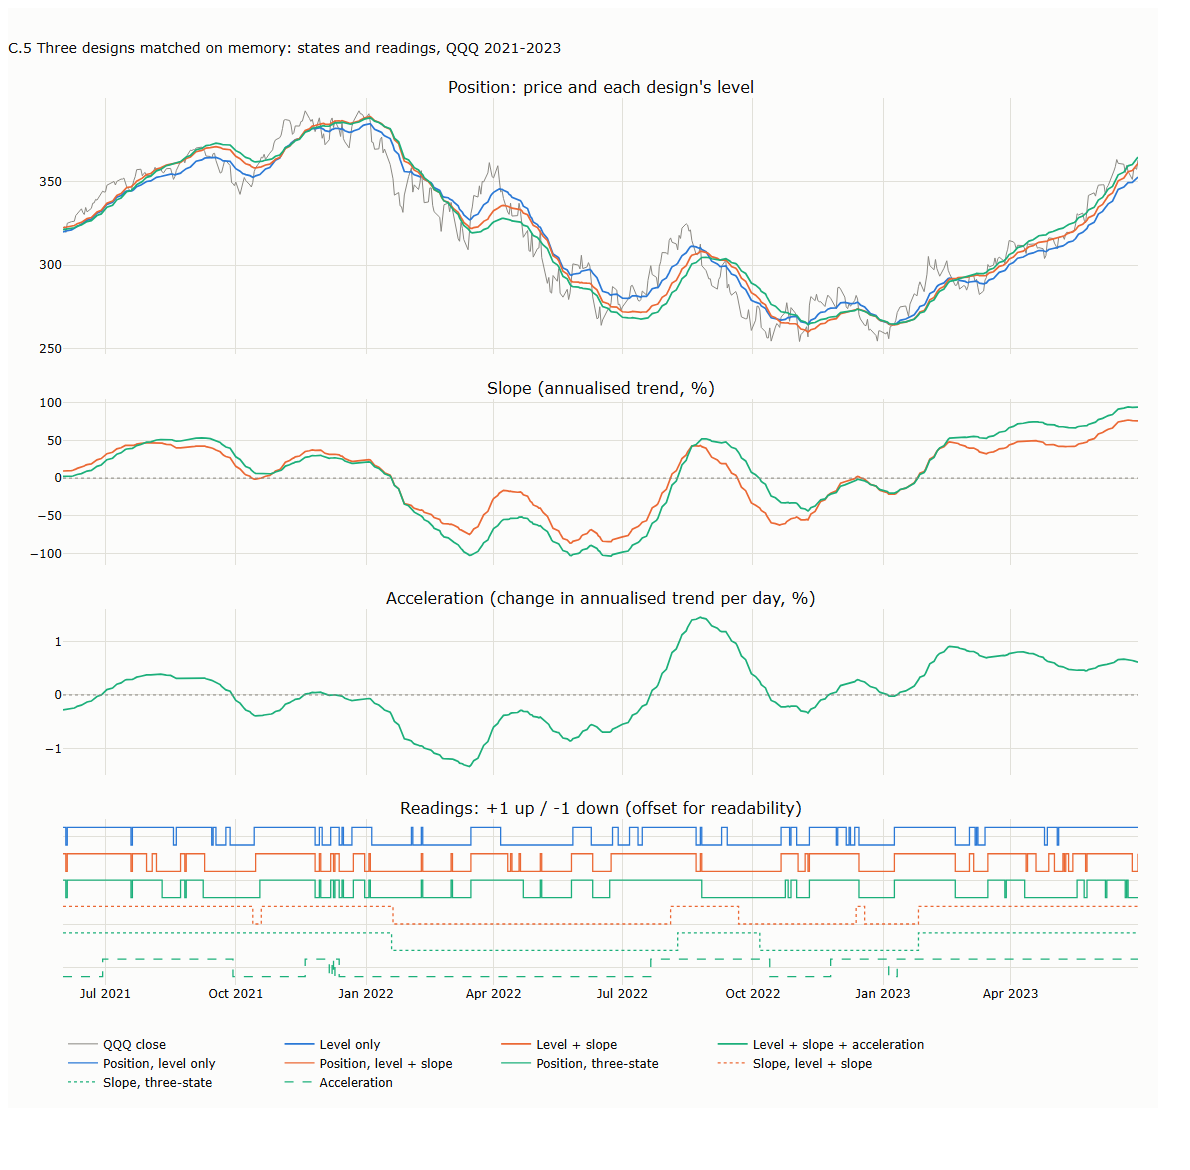

In [12]:
X = {k: run(y_qqq, k, R_MATCH[k])["states"] for k in (1, 2, 3)}
readings = pd.DataFrame({
    "Position, level only": np.sign(y_qqq - X[1][:, 0]), "Position, level + slope": np.sign(y_qqq - X[2][:, 0]),
    "Position, three-state": np.sign(y_qqq - X[3][:, 0]), "Slope, level + slope": np.sign(X[2][:, 1]),
    "Slope, three-state": np.sign(X[3][:, 1]), "Acceleration": np.sign(X[3][:, 2])}, index=dates)
R_ = readings.iloc[300:]
agree = (R_.T.dot(R_) / len(R_) * 0.5 + 0.5).round(2)
print("Share of days each pair of readings agrees (QQQ):")
display(agree)


def states_figure(lo, hi, title, name, shade=None):
    m = (dates >= lo) & (dates <= hi)
    fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.05, row_heights=[0.34, 0.22, 0.22, 0.22],
                        subplot_titles=("Position: price and each design's level", "Slope (annualised trend, %)",
                                        "Acceleration (change in annualised trend per day, %)", "Readings: +1 up / -1 down (offset for readability)"))
    fig.add_scatter(x=dates[m], y=qqq.to_numpy()[m], name="QQQ close", mode="lines", line=dict(width=1, color=MUTED), row=1, col=1)
    for j, k in enumerate((1, 2, 3)):
        fig.add_scatter(x=dates[m], y=np.exp(X[k][m, 0]), name=NAMES[k], mode="lines", line=dict(width=1.7, color=SERIES[j]), row=1, col=1)
    for j, k in ((1, 2), (2, 3)):
        fig.add_scatter(x=dates[m], y=100 * 252 * X[k][m, 1], showlegend=False, mode="lines", line=dict(width=1.7, color=SERIES[j]), row=2, col=1)
    fig.add_scatter(x=dates[m], y=100 * 252 * X[3][m, 2], showlegend=False, mode="lines", line=dict(width=1.7, color=SERIES[2]), row=3, col=1)
    cols = [SERIES[0], SERIES[1], SERIES[2], SERIES[1], SERIES[2], SERIES[2]]
    dash = ["solid", "solid", "solid", "dot", "dot", "dash"]
    for j, col in enumerate(readings):
        fig.add_scatter(x=dates[m], y=readings[col].to_numpy()[m] * 0.4 + (5 - j) * 1.2, name=col, mode="lines",
                        line=dict(width=1.3, color=cols[j], dash=dash[j], shape="hv"), row=4, col=1)
    for a, b in (shade or []):
        fig.add_vrect(x0=a, x1=b, fillcolor="rgba(120,120,120,0.10)", line_width=0)
    fig.update_yaxes(showticklabels=False, row=4, col=1)
    for r_ in (2, 3):
        fig.add_hline(y=0, line=dict(width=1, color=MUTED, dash="dot"), row=r_, col=1)
    fig.update_layout(title=title, height=1100, width=1150, margin=dict(t=90, b=80), legend=dict(orientation="h", y=-0.05, x=0))
    save_figure(fig, name, FIG)
    return fig


states_figure("2021-06-01", "2023-06-30", "C.5 Three designs matched on memory: states and readings, QQQ 2021-2023", "c05_three_designs")

## 8. The dials: shifting emphasis between states

The three-state design with four noise settings, each raising one entry of $Q$ a hundredfold from a
balanced case (price noise $R = 10^{-4}$). The settings are illustrative, not estimated.

,level roughness,level gap to price (RMS %),slope sign changes per year,days until slope < 0 after 2020-02-19 peak,days until slope > 0 after 2020-03-23 low
Balanced,0.33,2.24,8.01,6.0,15.0
Level emphasised,0.66,0.64,9.45,6.0,15.0
Slope emphasised,0.51,1.28,24.67,3.0,3.0
Acceleration emphasised,0.43,1.79,14.88,4.0,6.0


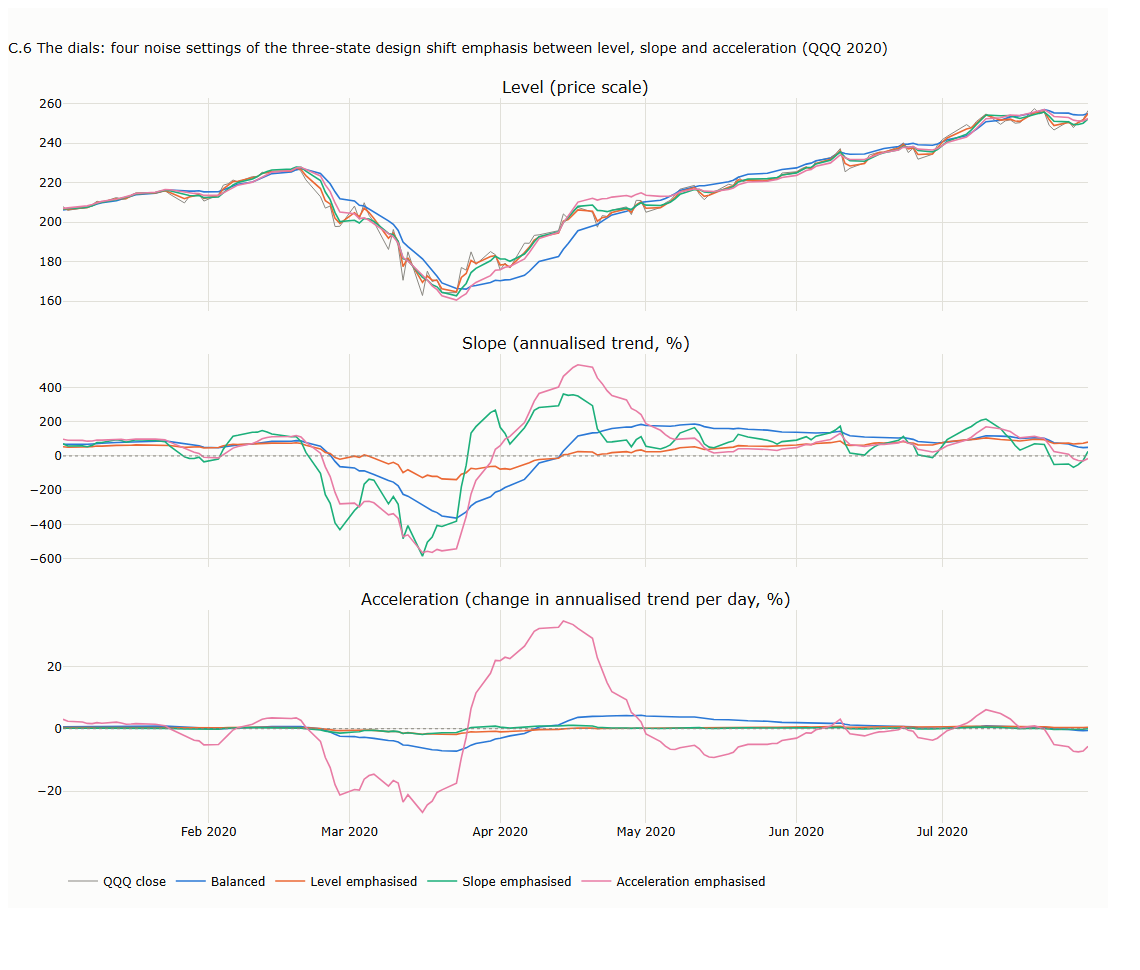

In [13]:
F3, H3 = design(3)
settings = {"Balanced": (1e-6, 1e-8, 1e-11), "Level emphasised": (1e-4, 1e-8, 1e-11),
            "Slope emphasised": (1e-6, 1e-6, 1e-11), "Acceleration emphasised": (1e-6, 1e-8, 1e-9)}
m = (dates >= "2020-01-01") & (dates <= "2020-07-31")
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
                    subplot_titles=("Level (price scale)", "Slope (annualised trend, %)", "Acceleration (change in annualised trend per day, %)"))
fig.add_scatter(x=dates[m], y=qqq.to_numpy()[m], name="QQQ close", mode="lines", line=dict(width=1, color=MUTED), row=1, col=1)
rows = {}
for j, (nm, q) in enumerate(settings.items()):
    Xs = kalman(y_qqq, F3, H3, np.array(q), 1e-4)["states"]
    for r_, (col, scale) in enumerate(((0, None), (1, 25200), (2, 25200)), start=1):
        yv = np.exp(Xs[m, 0]) if col == 0 else scale * Xs[m, col]
        fig.add_scatter(x=dates[m], y=yv, name=nm, showlegend=(r_ == 1), mode="lines", line=dict(width=1.6, color=SERIES[j]), row=r_, col=1)
    lvl, sl, yy = Xs[300:, 0], Xs[300:, 1], y_qqq[300:]
    s = pd.Series(Xs[:, 1], dates)

    def turn(d, sign):
        w = s.loc[d:]
        hit = w[np.sign(w) == sign]
        return dates.get_loc(hit.index[0]) - dates.get_loc(w.index[0])

    rows[nm] = {"level roughness": np.std(np.diff(lvl)) / np.std(np.diff(yy)), "level gap to price (RMS %)": 100 * np.sqrt(np.mean((lvl - yy) ** 2)),
                "slope sign changes per year": np.sum(np.diff(np.sign(sl)) != 0) / (len(sl) / 252),
                "days until slope < 0 after 2020-02-19 peak": turn("2020-02-19", -1), "days until slope > 0 after 2020-03-23 low": turn("2020-03-23", 1)}
for r_ in (2, 3):
    fig.add_hline(y=0, line=dict(width=1, color=MUTED, dash="dot"), row=r_, col=1)
fig.update_layout(title="C.6 The dials: four noise settings of the three-state design shift emphasis between level, slope and acceleration (QQQ 2020)",
                  height=900, width=1100, margin=dict(t=90, b=70), legend=dict(orientation="h", y=-0.06, x=0))
save_figure(fig, "c06_dials", FIG)
display(pd.DataFrame(rows).T.round(2))
fig

## 9. Starting the filter: warm-up

The level + slope design (matched) started 10% away from the true level, once with a confident start
(small starting uncertainty) and once with a *diffuse* start (large starting uncertainty), compared
with the same design started at the right level. EMA(20) started 10% off is shown for reference.

Kalman, confident start : starting error below 0.1% after 137 bars
Kalman, diffuse start   : starting error below 0.1% after 0 bars
EMA(20)                 : starting error below 0.1% after 70 bars


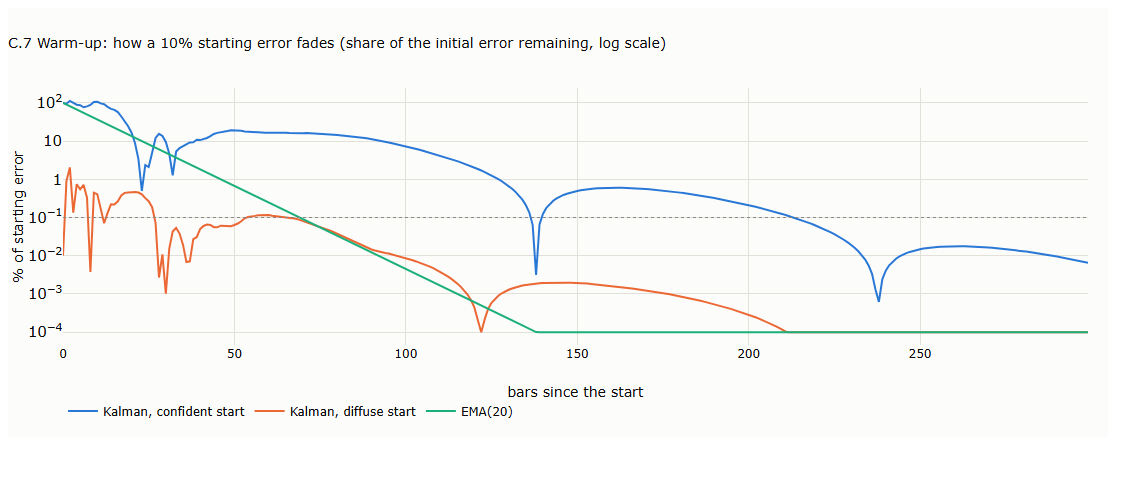

In [14]:
ref = run(y_qqq, 2, R_MATCH[2], start_uncertainty=1.0)["states"][:, 0]
off = np.log(1.1)
conf = run(y_qqq, 2, R_MATCH[2], start_uncertainty=1e-6, start_state=[y_qqq[0] + off, 0.0])["states"][:, 0]
diff_ = run(y_qqq, 2, R_MATCH[2], start_uncertainty=1e3, start_state=[y_qqq[0] + off, 0.0])["states"][:, 0]
e_ref = ema(y_qqq, alpha20)
e_off = ema(np.r_[y_qqq[0] + off, y_qqq[1:]], alpha20)
errs = {"Kalman, confident start": np.abs(conf - ref) / off, "Kalman, diffuse start": np.abs(diff_ - ref) / off,
        "EMA(20)": np.abs(e_off - e_ref) / off}
for nm, e in errs.items():
    below = np.where(e < 1e-3)[0]
    print(f"{nm:24s}: starting error below 0.1% after {below[0] if len(below) else 'never'} bars")
fig = go.Figure()
for j, (nm, e) in enumerate(errs.items()):
    fig.add_scatter(x=np.arange(300), y=100 * np.maximum(e[:300], 1e-6), name=nm, mode="lines", line=dict(width=2, color=SERIES[j]))
fig.add_hline(y=0.1, line=dict(width=1, color=MUTED, dash="dot"))
fig.update_layout(title="C.7 Warm-up: how a 10% starting error fades (share of the initial error remaining, log scale)",
                  xaxis_title="bars since the start", yaxis=dict(title="% of starting error", type="log", exponentformat="power"),
                  height=430, width=1100, margin=dict(t=80, b=70), legend=dict(orientation="h", y=-0.2, x=0))
save_figure(fig, "c07_warmup", FIG)
fig

**Warm-up by design.** For each design matched to EMA(20): how many bars the gain needs to settle,
how far back its memory reaches (older prices carry under 0.1% of the total absolute weight), and how
quickly a 10% starting error in the level, and the starting slope, are forgotten with a diffuse and a
confident start, measured against the same design started at the right level.

In [15]:
rows = {}
for k in (1, 2, 3):
    g = run(np.zeros(3000), k, R_MATCH[k], start_uncertainty=1e3)["gain"]
    settle = int(np.argmax(np.abs(g - g[-1]) < 0.01 * g[-1]))
    w = level_weights(k, R_MATCH[k], n=2000)
    tail = np.array([np.abs(w[j:]).sum() for j in range(len(w))]) / np.abs(w).sum()
    horizon = int(np.argmax(tail < 1e-3))
    ref_k = run(y_qqq, k, R_MATCH[k])["states"]
    s0 = np.zeros(k); s0[0] = y_qqq[0] + off
    row = {"gain settled within 1% (bars)": settle, "memory horizon (bars)": horizon}
    for nm, p0 in (("diffuse", 1e3), ("confident", 1e-6)):
        Xw = run(y_qqq, k, R_MATCH[k], start_uncertainty=p0, start_state=s0)["states"]
        e_lvl = np.abs(Xw[:, 0] - ref_k[:, 0]) / off
        b = np.where(e_lvl < 1e-3)[0]
        row[f"level error < 0.1%, {nm} start (bars)"] = int(b[0]) if len(b) else None
        if k >= 2:
            e_sl = 25200 * np.abs(Xw[:, 1] - ref_k[:, 1])
            later = np.where(e_sl >= 1.0)[0]
            row[f"slope within 1%/yr for good, {nm} start (bars)"] = int(later[-1] + 1) if len(later) else 0
    rows[NAMES[k]] = row
warm_tab = pd.DataFrame(rows).T
display(warm_tab)

,gain settled within 1% (bars),memory horizon (bars),"level error < 0.1%, diffuse start (bars)","level error < 0.1%, confident start (bars)","slope within 1%/yr for good, diffuse start (bars)","slope within 1%/yr for good, confident start (bars)"
Level only,26.0,70.0,0.0,73.0,NaN,NaN
Level + slope,86.0,197.0,0.0,137.0,24.0,163.0
Level + slope + acceleration,184.0,436.0,23.0,145.0,174.0,346.0


## 10. Extensions, profiled not ranked

Three changes to the level + slope design (matched), each describing a different belief about the data:

- **Robust update**: a surprise larger than 3 times the recent typical surprise (a running estimate
  over about a year, using past data only) is capped before correcting, a simple version of the idea in
  Masreliez and Martin (1977), motivated by fat-tailed surprises. The cap is relative to recent
  surprises rather than to the model's own surprise variance, because matching memory to EMA(20) sets
  the model's price noise far above the actual daily noise, and a cap on that scale would almost never bind.
- **Price noise from the bar's range**: $R$ changes every bar in proportion to the Parkinson variance
  of that bar (Lecture 3), scaled to the same average.
- **Damped slope**: the slope fades by a factor 0.98 per bar unless renewed by the data.

Normalised surprises of the level + slope design (standardised to unit variance):


,share |z| > 3 (%),normal would give (%),skewness,excess kurtosis
SPY,1.26,0.27,-0.64,5.87
QQQ,1.69,0.27,0.10,3.31
GLD,1.17,0.27,-0.23,2.07
AGG,1.77,0.27,-0.48,12.03


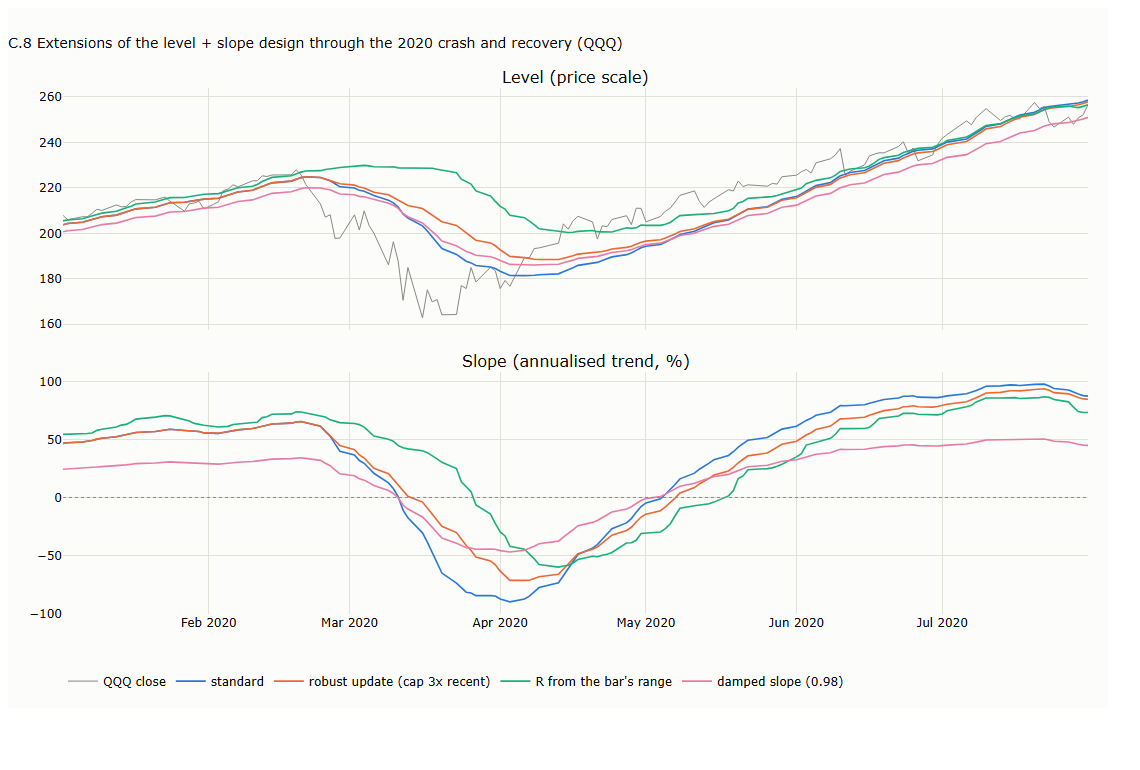

In [16]:
def parkinson(t):
    return (np.log(H[t] / L[t]) ** 2 / (4 * np.log(2))).reindex(C[t].dropna().index)


park_q = parkinson("QQQ").to_numpy()
park_q = np.maximum(park_q, np.nanquantile(park_q[park_q > 0], 0.01))
variants = {"standard": {}, "robust update (cap 3x recent)": {"cap": 3.0},
            "R from the bar's range": {"r_series": R_MATCH[2] * park_q / np.nanmean(park_q)},
            "damped slope (0.98)": {"damping": 0.98}}
VX = {nm: run(y_qqq, 2, R_MATCH[2], **kw) for nm, kw in variants.items()}
z_std = VX["standard"]["z"][300:]
tails = {}
for t in TICKERS:
    yt = np.log(C[t].dropna().to_numpy())
    zt = run(yt, 2, R_MATCH[2])["z"][300:]
    zt = zt / np.std(zt)
    tails[t] = {"share |z| > 3 (%)": 100 * np.mean(np.abs(zt) > 3), "normal would give (%)": 100 * 2 * norm.sf(3),
                "skewness": skew(zt), "excess kurtosis": kurtosis(zt)}
print("Normalised surprises of the level + slope design (standardised to unit variance):")
display(pd.DataFrame(tails).T.round(2))

m = (dates >= "2020-01-01") & (dates <= "2020-07-31")
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08, subplot_titles=("Level (price scale)", "Slope (annualised trend, %)"))
fig.add_scatter(x=dates[m], y=qqq.to_numpy()[m], name="QQQ close", mode="lines", line=dict(width=1, color=MUTED), row=1, col=1)
for j, (nm, out) in enumerate(VX.items()):
    fig.add_scatter(x=dates[m], y=np.exp(out["states"][m, 0]), name=nm, mode="lines", line=dict(width=1.6, color=SERIES[j]), row=1, col=1)
    fig.add_scatter(x=dates[m], y=25200 * out["states"][m, 1], showlegend=False, mode="lines", line=dict(width=1.6, color=SERIES[j]), row=2, col=1)
fig.add_hline(y=0, line=dict(width=1, color=MUTED, dash="dot"), row=2, col=1)
fig.update_layout(title="C.8 Extensions of the level + slope design through the 2020 crash and recovery (QQQ)",
                  height=700, width=1100, margin=dict(t=80, b=70), legend=dict(orientation="h", y=-0.1, x=0))
save_figure(fig, "c08_extensions_2020", FIG)
fig

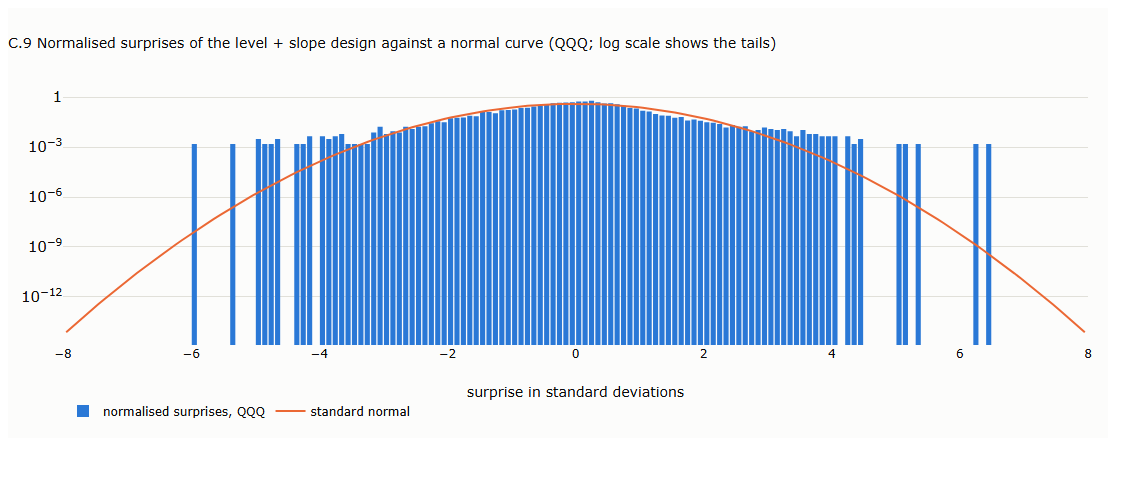

In [17]:
zs = z_std / np.std(z_std)
edges = np.linspace(-8, 8, 161)
counts, _ = np.histogram(zs, bins=edges)
centres = (edges[:-1] + edges[1:]) / 2
fig = go.Figure()
fig.add_bar(x=centres, y=counts / (len(zs) * np.diff(edges)), name="normalised surprises, QQQ", marker_color=SERIES[0])
fig.add_scatter(x=centres, y=norm.pdf(centres), name="standard normal", mode="lines", line=dict(width=2, color=SERIES[1]))
fig.update_layout(title="C.9 Normalised surprises of the level + slope design against a normal curve (QQQ; log scale shows the tails)",
                  yaxis=dict(type="log", exponentformat="power"), xaxis_title="surprise in standard deviations", height=430, width=1100,
                  margin=dict(t=80, b=70), legend=dict(orientation="h", y=-0.2, x=0))
save_figure(fig, "c09_surprises", FIG)
fig

## 11. A nonlinear case: hidden volatility from daily ranges

The hidden state is the log daily variance $h_t$ (a random walk); the measurement is the bar's high-low
range in log terms, $\text{range}_t = \ln(H_t/L_t)$. For a driftless Brownian motion with variance
$e^{h_t}$ over the day, $\text{range}_t = e^{h_t/2}\,\rho$, where $\rho$ is the range of a standard
Brownian motion over unit time (mean $\sqrt{8/\pi}$, Lecture 3). Two ways to filter it:

- **Nonlinear measurement** $\text{range}_t = e^{h_t/2}\,\mathbb E[\rho] + \text{noise}$: the extended
  (EKF) and unscented (UKF) filters.
- **Transform first**: $\ln \text{range}_t = h_t/2 + \mathbb E[\ln\rho] + \varepsilon_t$ is linear in
  $h_t$, so the ordinary Kalman filter applies (the route of Alizadeh, Brandt and Diebold, 2002).

The moments of $\rho$ and $\ln\rho$ are computed here by simulation on a fine grid (our calculation).

In [18]:
rng = np.random.default_rng(13)
n_paths, n_steps = 20000, 2000
rho = np.empty(n_paths)
for i in range(0, n_paths, 2000):
    w = np.cumsum(rng.standard_normal((2000, n_steps)) / np.sqrt(n_steps), axis=1)
    w = np.concatenate([np.zeros((2000, 1)), w], axis=1)
    rho[i:i + 2000] = w.max(axis=1) - w.min(axis=1)
mean_rho, var_rho = rho.mean(), rho.var()
mean_lr, var_lr = np.log(rho).mean(), np.log(rho).var()
print(f"range of a standard Brownian motion (simulated): mean {mean_rho:.4f} (sqrt(8/pi) = {np.sqrt(8 / np.pi):.4f}), variance {var_rho:.4f}")
print(f"log range: mean {mean_lr:.4f}, variance {var_lr:.4f}, skewness {skew(np.log(rho)):.3f}, excess kurtosis {kurtosis(np.log(rho)):.3f}")

range of a standard Brownian motion (simulated): mean 1.5720 (sqrt(8/pi) = 1.5958), variance 0.2266
log range: mean 0.4093, variance 0.0850, skewness 0.158, excess kurtosis -0.252


q for the log-variance random walk, by maximum likelihood on the linear model: 0.1259
Agreement between the three estimates of annualised session volatility (SPY):


,correlation with the linear filter,mean absolute difference (vol points)
linear on log range,1.000,0.000
extended (EKF) on range,0.946,0.972
unscented (UKF) on range,0.940,0.886


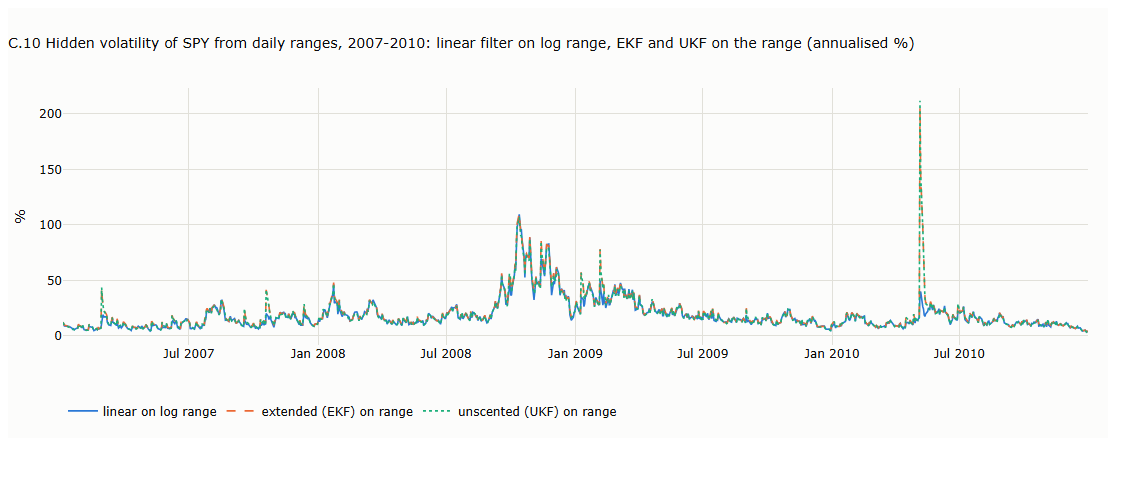

In [19]:
def vol_filters(rng_obs, q_h):
    T = len(rng_obs)
    out = {}
    # linear Kalman filter on log range
    h, P = np.log(np.nanmedian(rng_obs) ** 2 / mean_rho ** 2), 1.0
    lin, ll = np.empty(T), 0.0
    for t in range(T):
        P = P + q_h
        f = 0.5 * h + mean_lr
        S = 0.25 * P + var_lr
        e = np.log(rng_obs[t]) - f
        ll += -0.5 * (np.log(2 * np.pi * S) + e ** 2 / S)
        K = 0.5 * P / S
        h, P = h + K * e, (1 - 0.5 * K) * P
        lin[t] = h
    out["linear on log range"], out["loglik"] = lin, ll
    # extended Kalman filter on the range itself
    h, P = lin[0], 1.0
    ekf = np.empty(T)
    for t in range(T):
        P = P + q_h
        g = mean_rho * np.exp(h / 2)
        Hj = 0.5 * g
        Rm = np.exp(h) * var_rho
        S = Hj * P * Hj + Rm
        K = P * Hj / S
        h, P = h + K * (rng_obs[t] - g), (1 - K * Hj) * P
        ekf[t] = h
    out["extended (EKF) on range"] = ekf
    # unscented Kalman filter on the range itself (scalar state, 3 sigma points)
    alpha, beta, kappa = 1e-1, 2.0, 0.0
    lam = alpha ** 2 * (1 + kappa) - 1
    wm = np.array([lam / (1 + lam), 0.5 / (1 + lam), 0.5 / (1 + lam)])
    wc = wm.copy(); wc[0] += 1 - alpha ** 2 + beta
    h, P = lin[0], 1.0
    ukf = np.empty(T)
    for t in range(T):
        P = P + q_h
        sp = np.array([h, h + np.sqrt((1 + lam) * P), h - np.sqrt((1 + lam) * P)])
        g = mean_rho * np.exp(sp / 2)
        g_mean = wm @ g
        Rm = np.exp(h) * var_rho
        S = wc @ (g - g_mean) ** 2 + Rm
        Pxy = wc @ ((sp - h) * (g - g_mean))
        K = Pxy / S
        h, P = h + K * (rng_obs[t] - g_mean), P - K * S * K
        ukf[t] = h
    out["unscented (UKF) on range"] = ukf
    return out


spy_rng = np.log(H["SPY"] / L["SPY"]).reindex(C["SPY"].dropna().index)
spy_rng = spy_rng.clip(lower=spy_rng[spy_rng > 0].quantile(0.001)).to_numpy()
grid = np.logspace(-4, -0.5, 36)
lls = [vol_filters(spy_rng, q)["loglik"] for q in grid]
q_best = grid[int(np.argmax(lls))]
print(f"q for the log-variance random walk, by maximum likelihood on the linear model: {q_best:.4g}")
VF = vol_filters(spy_rng, q_best)
vol = {k: 100 * np.sqrt(252 * np.exp(v)) for k, v in VF.items() if k != "loglik"}
vdf = pd.DataFrame(vol, index=C["SPY"].dropna().index).iloc[100:]
print("Agreement between the three estimates of annualised session volatility (SPY):")
display(pd.DataFrame({"correlation with the linear filter": vdf.corr().iloc[0],
                      "mean absolute difference (vol points)": (vdf.sub(vdf.iloc[:, 0], axis=0)).abs().mean()}).round(3))
m = (vdf.index >= "2007-01-01") & (vdf.index <= "2010-12-31")
fig = go.Figure()
for j, col in enumerate(vdf):
    fig.add_scatter(x=vdf.index[m], y=vdf[col][m], name=col, mode="lines", line=dict(width=1.6, color=SERIES[j], dash=["solid", "dash", "dot"][j]))
fig.update_layout(title="C.10 Hidden volatility of SPY from daily ranges, 2007-2010: linear filter on log range, EKF and UKF on the range (annualised %)",
                  yaxis_title="%", height=430, width=1100, margin=dict(t=80, b=70), legend=dict(orientation="h", y=-0.2, x=0))
save_figure(fig, "c10_volatility_filters", FIG)
fig

## 12. What each design captures, by market condition

A profile, not a ranking. Market conditions are defined mechanically per asset (and are descriptive:
they classify a period after the fact; the readings themselves are causal):

- **Choppy**: 63-day efficiency ratio in the asset's bottom third. **Trending**: top third.
- **Strong advance**: 63-day log return in the asset's top 5%.
- **Turning points**: alternating highs and lows separated by a move of at least one year of the asset's
  typical volatility (a zigzag with a volatility-scaled threshold).

For each reading: sign changes per year in choppy and in trending conditions, the share of strong-advance
days pointing up, the median delay after a turning point until it points the new way, and the difference
in average 63-day forward log return between days it points up and days it points down (a description
of persistence, not a strategy).

In [20]:
def zigzag(series, threshold):
    pts, mode = [], None
    ext_i, ext_v = series.index[0], series.iloc[0]
    hi_i, hi_v, lo_i, lo_v = ext_i, ext_v, ext_i, ext_v
    for d, v in series.items():
        if mode in (None, "up"):
            if v > hi_v: hi_i, hi_v = d, v
            if v <= hi_v - threshold:
                pts.append(("high", hi_i)); mode = "down"; lo_i, lo_v = d, v
                continue
        if mode in (None, "down"):
            if v < lo_v: lo_i, lo_v = d, v
            if v >= lo_v + threshold:
                pts.append(("low", lo_i)); mode = "up"; hi_i, hi_v = d, v
    return pts


def log_series(t):
    s = C[t].dropna()
    return pd.Series(np.log(s.to_numpy()), index=s.index)


def describe(rd, yt):
    yv = yt.loc[rd.index]
    er = (yv - yv.shift(63)).abs() / yv.diff().abs().rolling(63).sum()
    choppy, trending = er <= er.quantile(1 / 3), er >= er.quantile(2 / 3)
    ret63 = yv - yv.shift(63)
    strong = ret63 >= ret63.quantile(0.95)
    fwd = yv.shift(-63) - yv
    thr = yv.diff().std() * np.sqrt(252)
    pts = zigzag(yv, thr)
    flips = rd.diff().abs() > 0
    res = {}
    for col in rd:
        delays = []
        for kind, d in pts:
            want = -1 if kind == "high" else 1
            w = rd[col].loc[d:].iloc[:252]
            hit = w[w == want]
            if len(hit): delays.append(rd.index.get_loc(hit.index[0]) - rd.index.get_loc(d))
        res[col] = {"sign changes/yr, choppy": flips[col][choppy].sum() / (choppy.sum() / 252),
                    "sign changes/yr, trending": flips[col][trending].sum() / (trending.sum() / 252),
                    "strong advance: share pointing up (%)": 100 * (rd[col][strong] > 0).mean(),
                    "median delay after turning points (days)": np.median(delays) if delays else np.nan,
                    "fwd 63d return, up minus down (% pts)": 100 * (fwd[rd[col] > 0].mean() - fwd[rd[col] < 0].mean())}
    return pd.DataFrame(res).T, len(pts)


def profile(t):
    yt = log_series(t)
    Xt = {k: run(yt.to_numpy(), k, R_MATCH[k])["states"] for k in (1, 2, 3)}
    rd = pd.DataFrame({"Position, level only": np.sign(yt - Xt[1][:, 0]), "Position, level + slope": np.sign(yt - Xt[2][:, 0]),
                       "Position, three-state": np.sign(yt - Xt[3][:, 0]), "Slope, level + slope": np.sign(Xt[2][:, 1]),
                       "Slope, three-state": np.sign(Xt[3][:, 1]), "Acceleration": np.sign(Xt[3][:, 2])}, index=yt.index).iloc[300:]
    return describe(rd, yt)


profiles = {}
for t in TICKERS:
    profiles[t], npts = profile(t)
    print(f"{t}: {npts} turning points")
prof = pd.concat(profiles, names=["asset", "reading"])
display(prof.round(1))
print("Median across the four assets:")
display(prof.groupby(level="reading", sort=False).median().round(1))

SPY: 23 turning points


QQQ: 15 turning points


GLD: 16 turning points


AGG: 13 turning points


sign changes/yr, choppy  \
asset reading                                            
SPY   Position, level only                        38.7   
      Position, level + slope                     27.5   
      Position, three-state                       21.9   
      Slope, level + slope                         6.6   
      Slope, three-state                           5.5   
      Acceleration                                 4.7   
QQQ   Position, level only                        37.9   
      Position, level + slope                     26.1   
      Position, three-state                       22.4   
      Slope, level + slope                         7.9   
      Slope, three-state                           5.9   
      Acceleration                                 4.5   
GLD   Position, level only                        36.3   
      Position, level + slope                     25.9   
      Position, three-state                       17.6   
      Slope, level + slope                         6.9   
      Slope, three-state                           5.1   
      Acceleration                                 4.3   
AGG   Position, level only                        42.3   
      Position, level + slope                     31.9   
      Position, three-state                       26.3   
      Slope, level + slope                         8.3   
      Slope, three-state                           4.3   
      Acceleration                                 3.1   

                               sign changes/yr, trending  \
asset reading                                              
SPY   Position, level only                          22.8   
      Position, level + slope                       36.0   
      Position, three-state                         25.5   
      Slope, level + slope                           0.0   
      Slope, three-state                             0.4   
      Acceleration                                   1.7   
QQQ   Position, level only                          23.1   
      Position, level + slope                       31.9   
      Position, three-state                         24.7   
      Slope, level + slope                           0.2   
      Slope, three-state                             0.5   
      Acceleration                                   1.8   
GLD   Position, level only                          25.0   
      Position, level + slope                       25.6   
      Position, three-state                         27.0   
      Slope, level + slope                           0.1   
      Slope, three-state                             1.0   
      Acceleration                                   1.9   
AGG   Position, level only                          21.3   
      Position, level + slope                       32.3   
      Position, three-state                         26.7   
      Slope, level + slope                           0.0   
      Slope, three-state                             0.4   
      Acceleration                                   1.9   

                               strong advance: share pointing up (%)  \
asset reading                                                          
SPY   Position, level only                                      94.1   
      Position, level + slope                                   65.3   
      Position, three-state                                     51.5   
      Slope, level + slope                                      99.8   
      Slope, three-state                                        99.8   
      Acceleration                                              94.3   
QQQ   Position, level only                                      91.8   
      Position, level + slope                                   62.0   
      Position, three-state                                     52.9   
      Slope, level + slope                                      99.4   
      Slope, three-state                                        98.5   
      Acceleration       

Median across the four assets:


,"sign changes/yr, choppy","sign changes/yr, trending",strong advance: share pointing up (%),median delay after turning points (days),"fwd 63d return, up minus down (% pts)"
reading,,,,,
"Position, level only",38.3,23.0,91.4,5.0,0.2
"Position, level + slope",26.8,32.1,65.0,4.2,-0.5
"Position, three-state",22.1,26.1,58.8,4.0,-0.4
"Slope, level + slope",7.4,0.1,99.9,29.5,1.0
"Slope, three-state",5.3,0.4,99.9,36.0,0.3
Acceleration,4.4,1.9,97.4,23.2,0.1


**The extensions of section 10, profiled the same way.** The level + slope design (matched) in its
standard form and with each extension; position and slope readings, same market conditions, median
across the four assets.

In [21]:
def ext_profile(t):
    yt = log_series(t)
    pk = parkinson(t).to_numpy()
    pk = np.maximum(pk, np.nanquantile(pk[pk > 0], 0.01))
    kws = {"standard": {}, "robust update": {"cap": 3.0}, "R from the range": {"r_series": R_MATCH[2] * pk / np.nanmean(pk)},
           "damped slope": {"damping": 0.98}}
    rd = {}
    for nm, kw in kws.items():
        Xs = run(yt.to_numpy(), 2, R_MATCH[2], **kw)["states"]
        rd[f"{nm}: position"] = np.sign(yt.to_numpy() - Xs[:, 0])
        rd[f"{nm}: slope"] = np.sign(Xs[:, 1])
    return describe(pd.DataFrame(rd, index=yt.index).iloc[300:], yt)[0]


ext = pd.concat({t: ext_profile(t) for t in TICKERS}, names=["asset", "reading"])
print("Extensions of the level + slope design, median across the four assets:")
display(ext.groupby(level="reading", sort=False).median().round(1))

Extensions of the level + slope design, median across the four assets:


,"sign changes/yr, choppy","sign changes/yr, trending",strong advance: share pointing up (%),median delay after turning points (days),"fwd 63d return, up minus down (% pts)"
reading,,,,,
standard: position,26.8,32.1,65.0,4.2,-0.5
standard: slope,7.4,0.1,99.9,29.5,1.0
robust update: position,26.7,31.8,66.3,4.2,-0.5
robust update: slope,7.3,0.1,99.9,29.5,0.9
R from the range: position,30.6,37.3,61.8,5.0,-0.2
R from the range: slope,8.9,0.5,99.9,26.5,0.8
damped slope: position,29.3,21.1,88.8,6.0,-0.1
damped slope: slope,7.1,0.1,99.9,29.5,1.0


## 13. Case studies

**The 2000 top.** A parabolic rise to March 2000, then a decline to October 2002 interrupted by sharp
counter-trend rallies. Rallies are identified mechanically: every rise of 20% or more off a low, ended
by a 20% fall. First, a check that the warm-up is complete by the peak (QQQ data start on 10 March 1999).

Level only                    : from the 2000 peak on, starting choices change the level by at most 0.000% and the slope by at most 0.00 %/yr


Level + slope                 : from the 2000 peak on, starting choices change the level by at most 0.000% and the slope by at most 0.01 %/yr


Level + slope + acceleration  : from the 2000 peak on, starting choices change the level by at most 0.167% and the slope by at most 1.21 %/yr
Counter-trend rallies: 2000-05-23 to 2000-09-01 (+37%), 2001-01-02 to 2001-01-23 (+27%), 2001-04-04 to 2001-05-21 (+50%), 2001-09-21 to 2001-12-06 (+52%), 2002-08-05 to 2002-08-22 (+22%)


,sign changes,share of days pointing up (%),rallies followed,days from each rally low until pointing up / rally length
"Position, level only",83,35,5 of 5,"4/72, 1/15, 5/33, 9/54, 3/14"
"Position, level + slope",79,43,5 of 5,"4/72, 1/15, 4/33, 8/54, 1/14"
"Position, three-state",67,45,5 of 5,"4/72, 1/15, 4/33, 10/54, 1/14"
"Slope, level + slope",9,25,2 of 5,"34/72, never/15, never/33, 38/54, never/14"
"Slope, three-state",7,28,2 of 5,"69/72, never/15, never/33, 44/54, never/14"
Acceleration,8,37,3 of 5,"61/72, never/15, 18/33, 34/54, never/14"


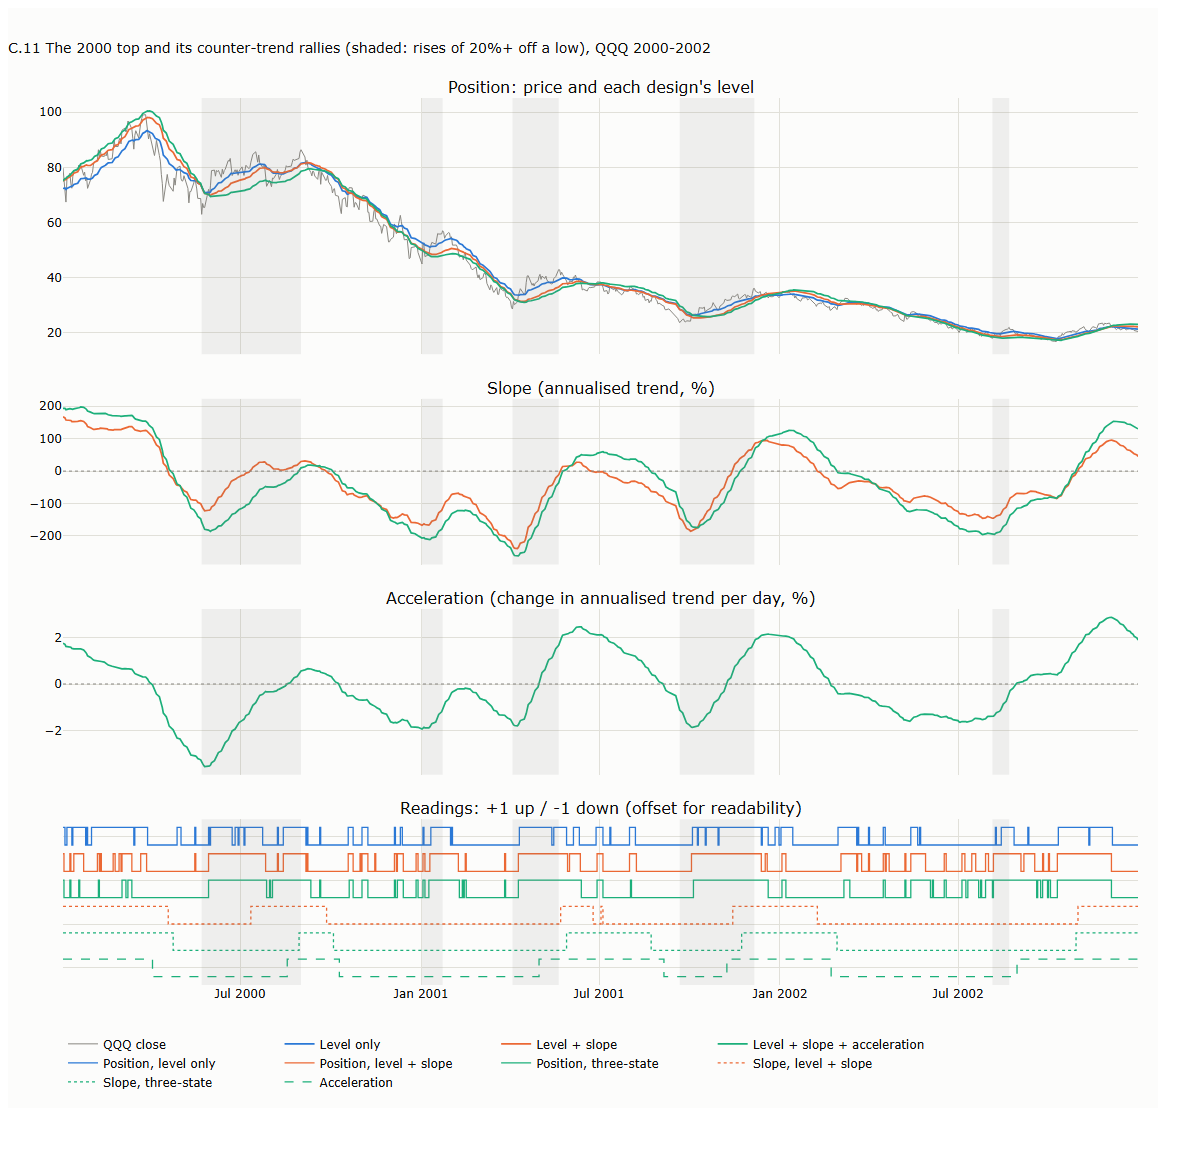

In [22]:
peak = dates.get_loc(pd.Timestamp("2000-03-10"))
for k in (1, 2, 3):
    a_ = run(y_qqq, k, R_MATCH[k], start_uncertainty=1.0)["states"]
    b_ = run(y_qqq, k, R_MATCH[k], start_uncertainty=1e-6)["states"]
    col = 1 if k > 1 else 0
    print(f"{NAMES[k]:30s}: from the 2000 peak on, starting choices change the level by at most {100 * np.abs(a_[peak:, 0] - b_[peak:, 0]).max():.3f}% "
          f"and the slope by at most {25200 * np.abs(a_[peak:, col] - b_[peak:, col]).max() if k > 1 else 0:.2f} %/yr")
seg = qqq.loc["2000-03-10":"2002-10-09"]
pts, mode = [], "down"
ext_i, ext_v = seg.index[0], seg.iloc[0]
for d, v in seg.items():
    if mode == "down":
        if v < ext_v: ext_v, ext_i = v, d
        elif v >= ext_v * 1.2: pts.append(("low", ext_i, ext_v)); mode, ext_v, ext_i = "up", v, d
    else:
        if v > ext_v: ext_v, ext_i = v, d
        elif v <= ext_v * 0.8: pts.append(("high", ext_i, ext_v)); mode, ext_v, ext_i = "down", v, d
rallies = [(pts[i][1], pts[i + 1][1], pts[i + 1][2] / pts[i][2] - 1) for i in range(len(pts) - 1) if pts[i][0] == "low" and pts[i + 1][0] == "high"]
bear = readings.loc["2000-03-10":"2002-10-09"]
rows = {}
for col in readings:
    per = []
    for a_, b_, r_ in rallies:
        w = readings[col].loc[a_:b_]
        hit = w[w > 0]
        per.append(f"{dates.get_loc(hit.index[0]) - dates.get_loc(a_)}/{len(w)}" if len(hit) else f"never/{len(w)}")
    rows[col] = {"sign changes": int((bear[col].diff().abs() > 0).sum()), "share of days pointing up (%)": round(100 * (bear[col] > 0).mean()),
                 "rallies followed": f"{sum(not p.startswith('never') for p in per)} of {len(per)}",
                 "days from each rally low until pointing up / rally length": ", ".join(per)}
print("Counter-trend rallies:", ", ".join(f"{a.date()} to {b.date()} (+{100 * r:.0f}%)" for a, b, r in rallies))
display(pd.DataFrame(rows).T)
states_figure("2000-01-01", "2002-12-31", "C.11 The 2000 top and its counter-trend rallies (shaded: rises of 20%+ off a low), QQQ 2000-2002",
              "c11_case_2000", shade=[(a, b) for a, b, _ in rallies])

**The 2020 V-shaped crash and recovery.** Two sharp turns about a month apart.

,days after the 2020-02-19 peak until pointing down,days after the 2020-03-23 low until pointing up,"sign changes, Feb-Jun 2020"
"Position, level only",3,3,6
"Position, level + slope",2,10,7
"Position, three-state",1,10,5
"Slope, level + slope",16,30,2
"Slope, three-state",18,40,2
Acceleration,13,39,2


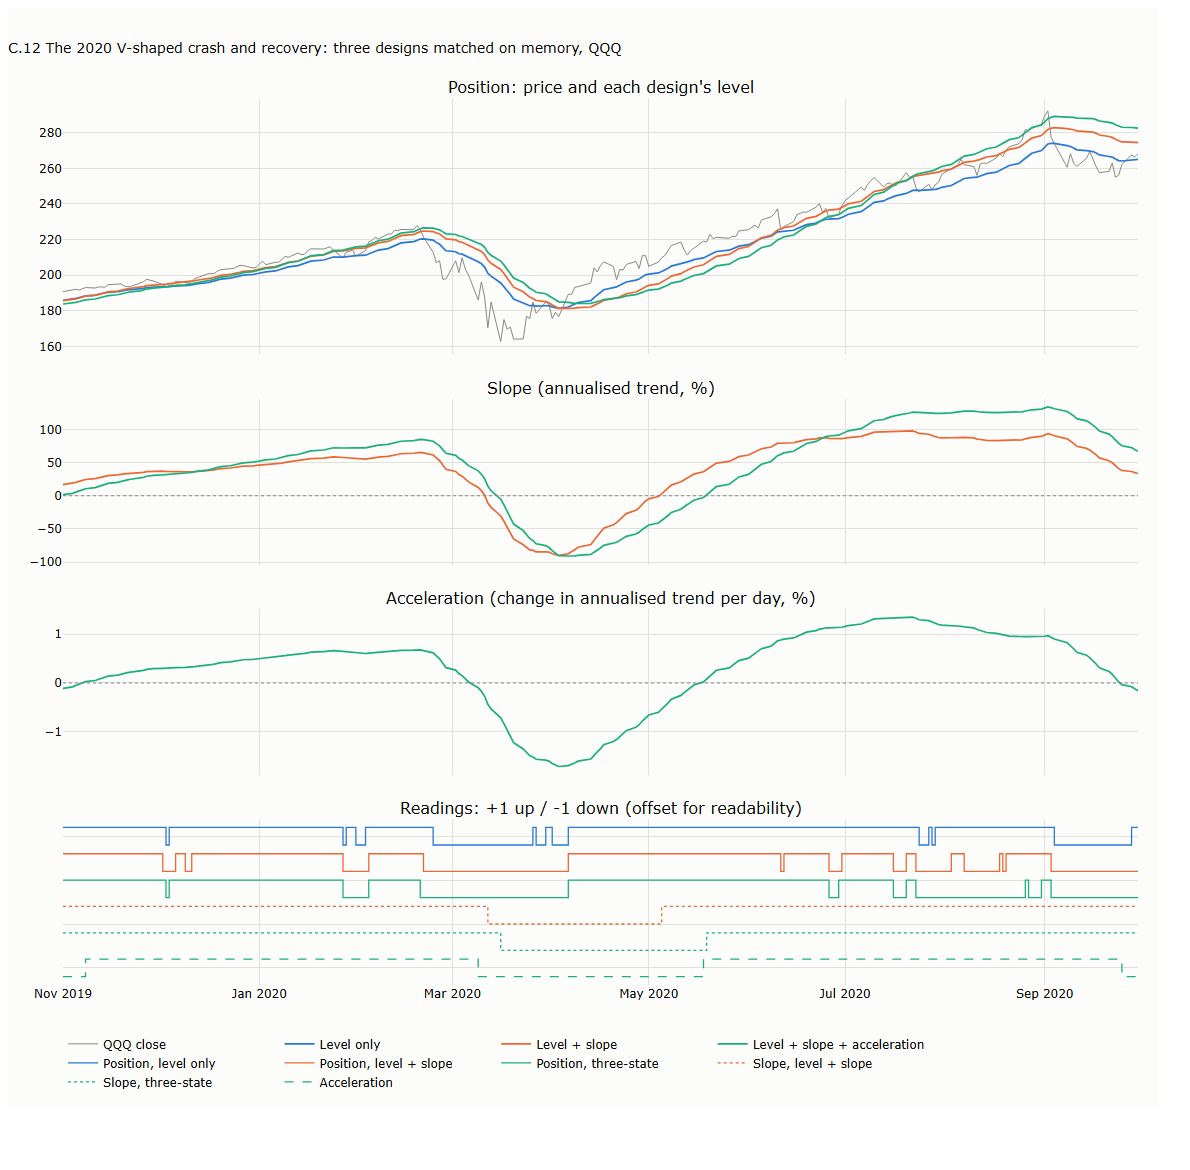

In [23]:
rows = {}
for col in readings:
    s = readings[col]

    def first(after, sign):
        w = s.loc[after:]
        hit = w[w == sign]
        return dates.get_loc(hit.index[0]) - dates.get_loc(w.index[0])

    rows[col] = {"days after the 2020-02-19 peak until pointing down": first("2020-02-19", -1),
                 "days after the 2020-03-23 low until pointing up": first("2020-03-23", 1),
                 "sign changes, Feb-Jun 2020": int((s.loc["2020-02-01":"2020-06-30"].diff().abs() > 0).sum())}
display(pd.DataFrame(rows).T)
states_figure("2019-11-01", "2020-09-30", "C.12 The 2020 V-shaped crash and recovery: three designs matched on memory, QQQ", "c12_case_2020")

## 14. A time-varying hedge ratio

The Kalman filter as a regression whose coefficients drift: QQQ's daily log return regressed on SPY's,
with the intercept and the hedge ratio (beta) as hidden states following random walks (the idea Chan,
2013, applies to an ETF pair). Compared with a rolling 63-day least-squares beta.

correlation of the Kalman beta with the rolling 63-day beta: 0.845
day-to-day variability (std of daily change): Kalman 0.0034, rolling 0.0193


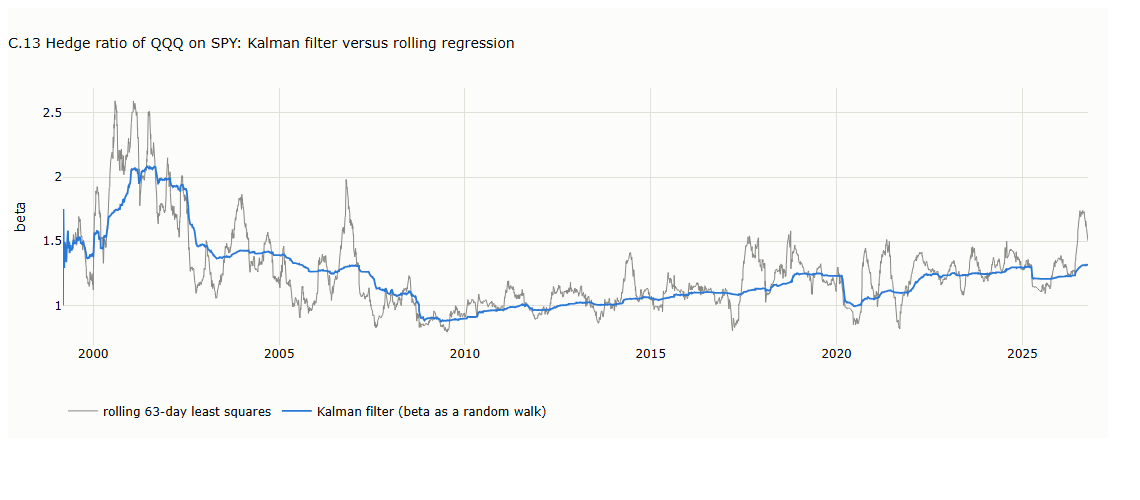

In [24]:
pair = pd.concat([np.log(C["QQQ"]).diff(), np.log(C["SPY"]).diff()], axis=1, keys=["QQQ", "SPY"]).dropna()
ya, xa = pair["QQQ"].to_numpy(), pair["SPY"].to_numpy()
state, P = np.array([0.0, 1.0]), np.eye(2)
Qb, Rb = np.diag([1e-8, 1e-5]), np.var(ya - xa)
betas = np.empty(len(ya))
for t in range(len(ya)):
    P = P + Qb
    h = np.array([1.0, xa[t]])
    S = h @ P @ h + Rb
    K = P @ h / S
    state = state + K * (ya[t] - h @ state)
    P = P - np.outer(K, h @ P)
    betas[t] = state[1]
kb = pd.Series(betas, index=pair.index)
roll = pair["QQQ"].rolling(63).cov(pair["SPY"]) / pair["SPY"].rolling(63).var()
print(f"correlation of the Kalman beta with the rolling 63-day beta: {kb.iloc[300:].corr(roll.iloc[300:]):.3f}")
print(f"day-to-day variability (std of daily change): Kalman {kb.diff().iloc[300:].std():.4f}, rolling {roll.diff().iloc[300:].std():.4f}")
fig = go.Figure()
fig.add_scatter(x=roll.index, y=roll, name="rolling 63-day least squares", mode="lines", line=dict(width=1, color=MUTED))
fig.add_scatter(x=kb.index, y=kb, name="Kalman filter (beta as a random walk)", mode="lines", line=dict(width=1.8, color=SERIES[0]))
fig.update_layout(title="C.13 Hedge ratio of QQQ on SPY: Kalman filter versus rolling regression", yaxis_title="beta",
                  height=430, width=1100, margin=dict(t=80, b=70), legend=dict(orientation="h", y=-0.2, x=0))
save_figure(fig, "c13_hedge_ratio", FIG)
fig

## References

- Alizadeh, S., Brandt, M. and Diebold, F. (2002). Range-based estimation of stochastic volatility models. *Journal of Finance* 57(3), 1047–1091.
- Chan, E. (2013). *Algorithmic Trading: Winning Strategies and Their Rationale.* Wiley.
- Durbin, J. and Koopman, S.J. (2012). *Time Series Analysis by State Space Methods* (2nd ed.). Oxford University Press.
- Harvey, A. (1989). *Forecasting, Structural Time Series Models and the Kalman Filter.* Cambridge University Press.
- Julier, S. and Uhlmann, J. (1997). A new extension of the Kalman filter to nonlinear systems. *Proc. SPIE* 3068, 182–193.
- Julier, S. and Uhlmann, J. (2004). Unscented filtering and nonlinear estimation. *Proceedings of the IEEE* 92(3), 401–422.
- Kalman, R.E. (1960). A new approach to linear filtering and prediction problems. *Journal of Basic Engineering* 82(1), 35–45.
- Masreliez, C. and Martin, R.D. (1977). Robust Bayesian estimation for the linear model and robustifying the Kalman filter. *IEEE Transactions on Automatic Control* 22(3), 361–371.
- Mehra, R. (1970). On the identification of variances and adaptive Kalman filtering. *IEEE Transactions on Automatic Control* 15(2), 175–184.